# Deteção de anomalias nos CPE com base nas features extraídas

Este notebook identifica CPE com comportamento anómalo, com base nas features agregadas e nos clusters previamente identificados.

Pretende-se:
- comparar múltiplos métodos de deteção de anomalias;
- comparar deteção global com deteção contextual (por cluster);
- analisar quais features mais contribuem para a classificação;
- quantificar a concordância entre métodos;
- reutilizar os modelos persistidos (scaler, PCA) para consistência visual.

In [1]:
# Imports e configuração

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
 
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
 
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
 
results_dir = Path("../results")
models_dir = Path("../results/models")

In [2]:
# Carregamento dos dados e modelos persistidos

features = pd.read_csv(results_dir / "features_cpe.csv", index_col=0)
clusters = pd.read_csv(results_dir / "clusters_cpe.csv", index_col=0)
 
print("Features:", features.shape)
print("Clusters:", clusters.shape)
 
# Carregar modelos do notebook de clustering (garante consistência)
scaler = joblib.load(models_dir / "scaler.pkl")
pca = joblib.load(models_dir / "pca.pkl")
 
print("\nModelos carregados:")
print(f"  Scaler: {models_dir / 'scaler.pkl'}")
print(f"  PCA: {models_dir / 'pca.pkl'}")
 
# Juntar features com informação de cluster
df_anom = features.join(clusters[["cluster"]], how="inner")
 
print(f"\nDistribuição por cluster:")
display(df_anom["cluster"].value_counts())
 
# Separar outliers prévios (do clustering) dos normais
df_anom_clean = df_anom[df_anom["cluster"] != "outlier"].copy()
df_anom_outliers_previos = df_anom[df_anom["cluster"] == "outlier"].copy()
 
print(f"\nShape sem outliers prévios: {df_anom_clean.shape}")
print(f"Outliers prévios: {df_anom_outliers_previos.shape[0]}")

Features: (90, 26)
Clusters: (90, 27)

Modelos carregados:
  Scaler: ..\results\models\scaler.pkl
  PCA: ..\results\models\pca.pkl

Distribuição por cluster:


cluster
4          22
1          22
2          15
8          12
3           5
0           4
6           3
9           3
outlier     2
5           1
7           1
Name: count, dtype: int64


Shape sem outliers prévios: (88, 27)
Outliers prévios: 2


# Observações

Os modelos (scaler, PCA) são reutilizados do notebook de clustering para garantir que as visualizações PCA são consistentes entre notebooks. Os CPE previamente classificados como outliers são mantidos separados.

In [3]:
# Preparação dos dados

X = df_anom_clean.drop(columns=["cluster"])
 
# Usar o mesmo scaler do clustering
X_scaled = scaler.transform(X)
 
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
 
# Usar o mesmo PCA do clustering
X_pca = pca.transform(X_scaled)
df_pca = pd.DataFrame(X_pca, index=X.index, columns=["PC1", "PC2"])
 
explained_variance = pca.explained_variance_ratio_
print(f"Variância explicada (PCA reutilizado):")
print(f"  PC1: {explained_variance[0]:.2%}")
print(f"  PC2: {explained_variance[1]:.2%}")

Variância explicada (PCA reutilizado):
  PC1: 26.82%
  PC2: 16.92%


In [4]:
# Deteção GLOBAL de anomalias - comparação de métodos

print("DETEÇÃO GLOBAL DE ANOMALIAS")
 
CONTAMINATION = 0.05
 
metodos_global = {}
 
# Isolation Forest
iso = IsolationForest(contamination=CONTAMINATION, random_state=42)
labels_iso = iso.fit_predict(X_scaled)
scores_iso = iso.decision_function(X_scaled)
 
metodos_global["IsolationForest"] = {
    "labels": labels_iso,
    "scores": scores_iso,
    "n_anomalias": (labels_iso == -1).sum(),
}
 
# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=10, contamination=CONTAMINATION)
labels_lof = lof.fit_predict(X_scaled)
scores_lof = lof.negative_outlier_factor_
 
metodos_global["LOF"] = {
    "labels": labels_lof,
    "scores": scores_lof,
    "n_anomalias": (labels_lof == -1).sum(),
}
 
# Elliptic Envelope
try:
    ee = EllipticEnvelope(contamination=CONTAMINATION, random_state=42)
    labels_ee = ee.fit_predict(X_scaled)
    scores_ee = ee.decision_function(X_scaled)
    
    metodos_global["EllipticEnvelope"] = {
        "labels": labels_ee,
        "scores": scores_ee,
        "n_anomalias": (labels_ee == -1).sum(),
    }
except Exception as e:
    print(f"  EllipticEnvelope falhou (possível singularidade): {e}")
 
# Tabela comparativa global
print(f"\nContamination: {CONTAMINATION}")
for method, res in metodos_global.items():
    anomalos = X.index[res["labels"] == -1].tolist()
    print(f"\n  {method}: {res['n_anomalias']} anomalias")
    print(f"    CPEs: {anomalos}")

DETEÇÃO GLOBAL DE ANOMALIAS

Contamination: 0.05

  IsolationForest: 5 anomalias
    CPEs: ['PT0002000068856781NM', 'PT0002000068859325FL', 'PT0002000068859597LS', 'PT0002000081997398TD', 'PT0002000100113293JT']

  LOF: 5 anomalias
    CPEs: ['PT0002000065256275YB', 'PT0002000068856781NM', 'PT0002000068859325FL', 'PT0002000105483259QH', 'PT0002000201936109ME']

  EllipticEnvelope: 5 anomalias
    CPEs: ['PT0002000068856781NM', 'PT0002000068859325FL', 'PT0002000068859393XH', 'PT0002000081997398TD', 'PT0002000100113293JT']


c:\Users\gui30\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-140.552577159902199 > -141.805340128397432). You may want to try with a higher value of support_fraction (current value: 0.659).
  warnings.warn(
c:\Users\gui30\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-108.252639294260348 > -112.109290398859102). You may want to try with a higher value of support_fraction (current value: 0.659).
  warnings.warn(
c:\Users\gui30\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:185: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-141.419635606893848 > -142.112782787454847). You may want

CONCORDÂNCIA ENTRE MÉTODOS (GLOBAL)

CPEs classificados como anómalos por número de métodos:


n_metodos_anomalo
0    79
1     5
2     2
3     2
Name: count, dtype: int64


CPEs anómalos por consenso (≥2 métodos): 4
  PT0002000068856781NM → detetado por: IsolationForest, LOF, EllipticEnvelope
  PT0002000068859325FL → detetado por: IsolationForest, LOF, EllipticEnvelope
  PT0002000081997398TD → detetado por: IsolationForest, EllipticEnvelope
  PT0002000100113293JT → detetado por: IsolationForest, EllipticEnvelope

Matriz de concordância (% de acordo):


,IsolationForest,LOF,EllipticEnvelope
IsolationForest,1.000,0.932,0.977
LOF,0.932,1.000,0.932
EllipticEnvelope,0.977,0.932,1.000


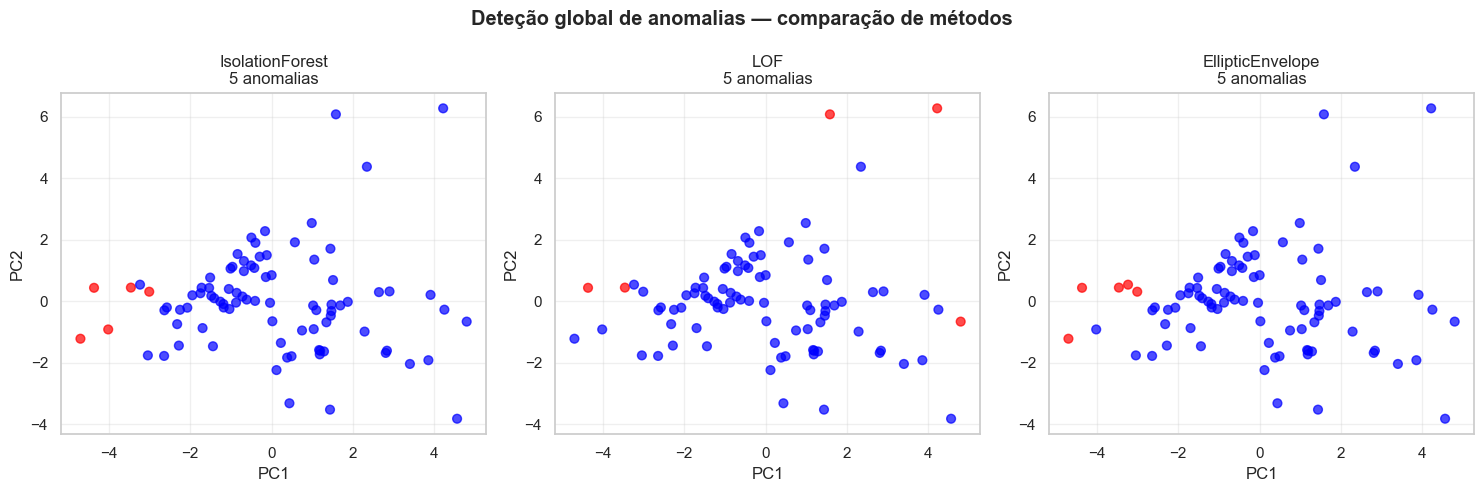

In [5]:
# Concordância entre métodos (global)

# Criar dataframe de concordância
df_concordancia = pd.DataFrame(index=X.index)
for method, res in metodos_global.items():
    df_concordancia[method] = np.where(res["labels"] == -1, 1, 0)
 
# Número de métodos que classificam cada CPE como anómalo
df_concordancia["n_metodos_anomalo"] = df_concordancia.sum(axis=1)
df_concordancia["anomalia_consenso"] = np.where(
    df_concordancia["n_metodos_anomalo"] >= 2, "anomalia", "normal"
)
 
print("CONCORDÂNCIA ENTRE MÉTODOS (GLOBAL)")
 
print(f"\nCPEs classificados como anómalos por número de métodos:")
display(df_concordancia["n_metodos_anomalo"].value_counts().sort_index())
 
# CPEs anómalos por consenso (≥2 métodos concordam)
cpes_anomalos_consenso = df_concordancia[df_concordancia["anomalia_consenso"] == "anomalia"].index.tolist()
print(f"\nCPEs anómalos por consenso (≥2 métodos): {len(cpes_anomalos_consenso)}")
for cpe in cpes_anomalos_consenso:
    metodos = [m for m in metodos_global if df_concordancia.loc[cpe, m] == 1]
    print(f"  {cpe} → detetado por: {', '.join(metodos)}")
 
# Matriz de concordância entre pares de métodos
method_names = list(metodos_global.keys())
concordancia_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
 
for m1 in method_names:
    for m2 in method_names:
        concordancia_matrix.loc[m1, m2] = (df_concordancia[m1] == df_concordancia[m2]).mean()
 
print("\nMatriz de concordância (% de acordo):")
display(concordancia_matrix.round(3))
 
# Visualização PCA — todos os métodos
fig, axes = plt.subplots(1, len(metodos_global), figsize=(5*len(metodos_global), 5))
if len(metodos_global) == 1:
    axes = [axes]
 
for ax, (method, res) in zip(axes, metodos_global.items()):
    colors = ["red" if l == -1 else "blue" for l in res["labels"]]
    ax.scatter(df_pca["PC1"], df_pca["PC2"], c=colors, alpha=0.7, s=40)
    ax.set_title(f"{method}\n{res['n_anomalias']} anomalias")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)
 
plt.suptitle("Deteção global de anomalias — comparação de métodos", fontweight="bold")
plt.tight_layout()
plt.savefig(results_dir / "anomalias_globais_comparacao.png", dpi=150)
plt.show()

In [6]:
# Deteção CONTEXTUAL de anomalias (por cluster)

print("DETEÇÃO CONTEXTUAL DE ANOMALIAS (POR CLUSTER)")
 
# Aplicar cada método dentro de cada cluster
metodos_cluster = {m: {} for m in ["IsolationForest", "LOF", "EllipticEnvelope"]}
 
df_cluster_results = df_anom_clean.copy()
 
for method_name in metodos_cluster:
    df_cluster_results[f"{method_name}_label"] = "normal"
    df_cluster_results[f"{method_name}_score"] = np.nan
 
for cluster_id in sorted(df_anom_clean["cluster"].unique()):
    
    df_c = df_anom_clean[df_anom_clean["cluster"] == cluster_id]
    X_c = df_c.drop(columns=["cluster"])
    
    # Normalizar DENTRO do cluster
    scaler_c = StandardScaler()
    X_c_scaled = scaler_c.fit_transform(X_c)
    
    n_samples = len(X_c)
    print(f"\nCluster {cluster_id} ({n_samples} CPEs)")
    
    # Isolation Forest
    try:
        iso_c = IsolationForest(contamination=CONTAMINATION, random_state=42)
        labels_c = iso_c.fit_predict(X_c_scaled)
        scores_c = iso_c.decision_function(X_c_scaled)
        
        df_cluster_results.loc[df_c.index, "IsolationForest_label"] = [
            "anomalia" if l == -1 else "normal" for l in labels_c
        ]
        df_cluster_results.loc[df_c.index, "IsolationForest_score"] = scores_c
        print(f"  IsolationForest: {(labels_c == -1).sum()} anomalias")
    except Exception as e:
        print(f"  IsolationForest falhou: {e}")
    
    # LOF
    try:
        n_neighbors = min(10, n_samples - 1)
        lof_c = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=CONTAMINATION)
        labels_c = lof_c.fit_predict(X_c_scaled)
        scores_c = lof_c.negative_outlier_factor_
        
        df_cluster_results.loc[df_c.index, "LOF_label"] = [
            "anomalia" if l == -1 else "normal" for l in labels_c
        ]
        df_cluster_results.loc[df_c.index, "LOF_score"] = scores_c
        print(f"  LOF: {(labels_c == -1).sum()} anomalias")
    except Exception as e:
        print(f"  LOF falhou: {e}")
    
    # Elliptic Envelope
    try:
        if n_samples > X_c.shape[1]:  # precisa de mais amostras que features
            ee_c = EllipticEnvelope(contamination=CONTAMINATION, random_state=42)
            labels_c = ee_c.fit_predict(X_c_scaled)
            scores_c = ee_c.decision_function(X_c_scaled)
            
            df_cluster_results.loc[df_c.index, "EllipticEnvelope_label"] = [
                "anomalia" if l == -1 else "normal" for l in labels_c
            ]
            df_cluster_results.loc[df_c.index, "EllipticEnvelope_score"] = scores_c
            print(f"  EllipticEnvelope: {(labels_c == -1).sum()} anomalias")
        else:
            print(f"  EllipticEnvelope: cluster demasiado pequeno ({n_samples} < {X_c.shape[1]} features)")
    except Exception as e:
        print(f"  EllipticEnvelope falhou: {e}")

DETEÇÃO CONTEXTUAL DE ANOMALIAS (POR CLUSTER)

Cluster 0 (4 CPEs)
  IsolationForest: 1 anomalias
  LOF: 1 anomalias
  EllipticEnvelope: cluster demasiado pequeno (4 < 26 features)

Cluster 1 (22 CPEs)
  IsolationForest: 2 anomalias
  LOF: 2 anomalias
  EllipticEnvelope: cluster demasiado pequeno (22 < 26 features)

Cluster 2 (15 CPEs)
  IsolationForest: 1 anomalias
  LOF: 1 anomalias
  EllipticEnvelope: cluster demasiado pequeno (15 < 26 features)

Cluster 3 (5 CPEs)
  IsolationForest: 1 anomalias
  LOF: 1 anomalias
  EllipticEnvelope: cluster demasiado pequeno (5 < 26 features)

Cluster 4 (22 CPEs)
  IsolationForest: 2 anomalias
  LOF: 2 anomalias
  EllipticEnvelope: cluster demasiado pequeno (22 < 26 features)

Cluster 5 (1 CPEs)
  IsolationForest: 0 anomalias
  LOF falhou: The 'n_neighbors' parameter of LocalOutlierFactor must be an int in the range [1, inf) or None. Got 0 instead.
  EllipticEnvelope: cluster demasiado pequeno (1 < 26 features)

Cluster 6 (3 CPEs)
  IsolationForest:

In [7]:
# Concordância entre métodos (por cluster)

print("CONCORDÂNCIA ENTRE MÉTODOS (POR CLUSTER)")
 
label_cols = [c for c in df_cluster_results.columns if c.endswith("_label")]
 
df_cluster_results["n_metodos_anomalo_cluster"] = 0
for col in label_cols:
    df_cluster_results["n_metodos_anomalo_cluster"] += (df_cluster_results[col] == "anomalia").astype(int)
 
df_cluster_results["anomalia_consenso_cluster"] = np.where(
    df_cluster_results["n_metodos_anomalo_cluster"] >= 2, "anomalia", "normal"
)
 
print(f"\nDistribuição de concordância por cluster:")
display(
    df_cluster_results.groupby("cluster")["anomalia_consenso_cluster"]
    .value_counts()
    .unstack(fill_value=0)
)
 
# CPEs anómalos por consenso contextual
cpes_anom_cluster = df_cluster_results[
    df_cluster_results["anomalia_consenso_cluster"] == "anomalia"
].index.tolist()
 
print(f"\nCPEs anómalos por consenso contextual (≥2 métodos): {len(cpes_anom_cluster)}")
for cpe in cpes_anom_cluster:
    cluster = df_cluster_results.loc[cpe, "cluster"]
    n_met = df_cluster_results.loc[cpe, "n_metodos_anomalo_cluster"]
    print(f"  {cpe} (cluster {cluster}) → {n_met} métodos concordam")

CONCORDÂNCIA ENTRE MÉTODOS (POR CLUSTER)

Distribuição de concordância por cluster:


anomalia_consenso_cluster,anomalia,normal
cluster,,
0,0,4
1,2,20
2,0,15
3,0,5
4,1,21
5,0,1
6,0,3
7,0,1
8,1,11



CPEs anómalos por consenso contextual (≥2 métodos): 4
  PT0002000081997398TD (cluster 8) → 2 métodos concordam
  PT0002000112989585PH (cluster 4) → 2 métodos concordam
  PT0002000115673471CB (cluster 1) → 2 métodos concordam
  PT0002000133505542CK (cluster 1) → 2 métodos concordam



COMPARAÇÃO: GLOBAL vs CONTEXTUAL

Crosstab Global vs Contextual (consenso ≥2 métodos):


anomalia_cluster,anomalia,normal,All
anomalia_global,,,
anomalia,1,3,4
normal,3,81,84
All,4,84,88



Anómalo global mas normal no cluster: 3 CPEs
  → Estes CPEs são 'diferentes do global' mas normais dentro do seu grupo


,cluster,anomalia_global,anomalia_cluster
CPE,,,
PT0002000068856781NM,3,anomalia,normal
PT0002000068859325FL,3,anomalia,normal
PT0002000100113293JT,3,anomalia,normal



Normal global mas anómalo no cluster: 3 CPEs
  → Estes CPEs parecem normais globalmente mas são atípicos no seu grupo


,cluster,anomalia_global,anomalia_cluster
CPE,,,
PT0002000112989585PH,4,normal,anomalia
PT0002000115673471CB,1,normal,anomalia
PT0002000133505542CK,1,normal,anomalia


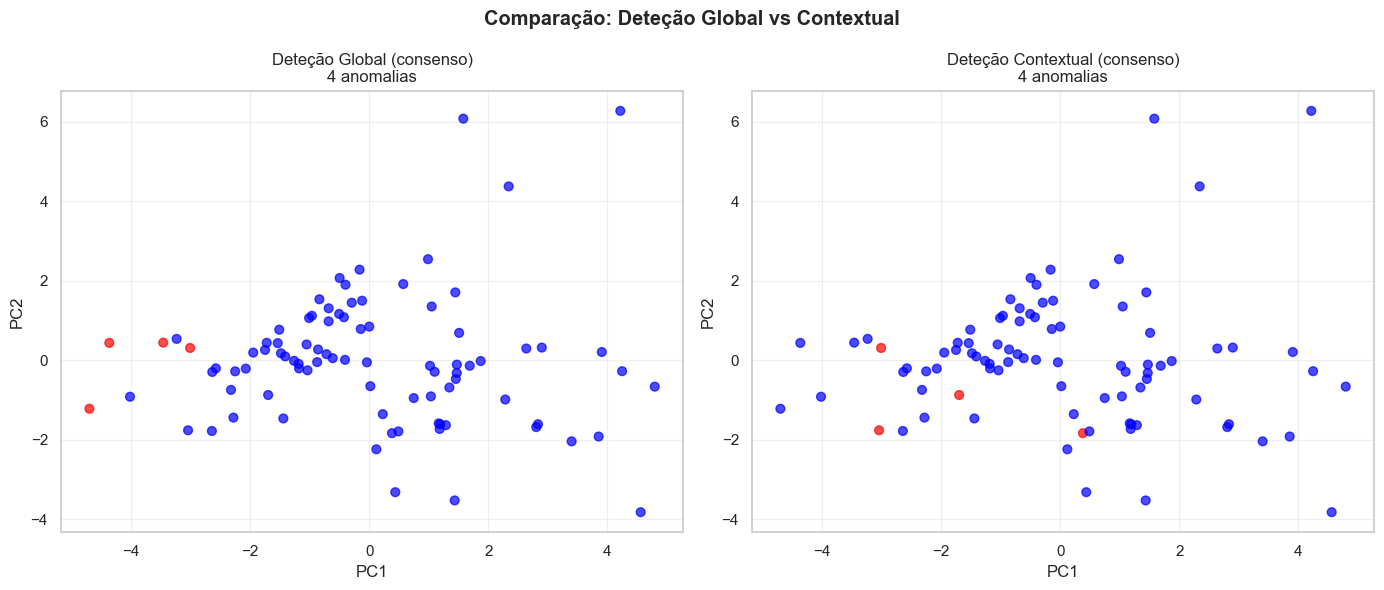

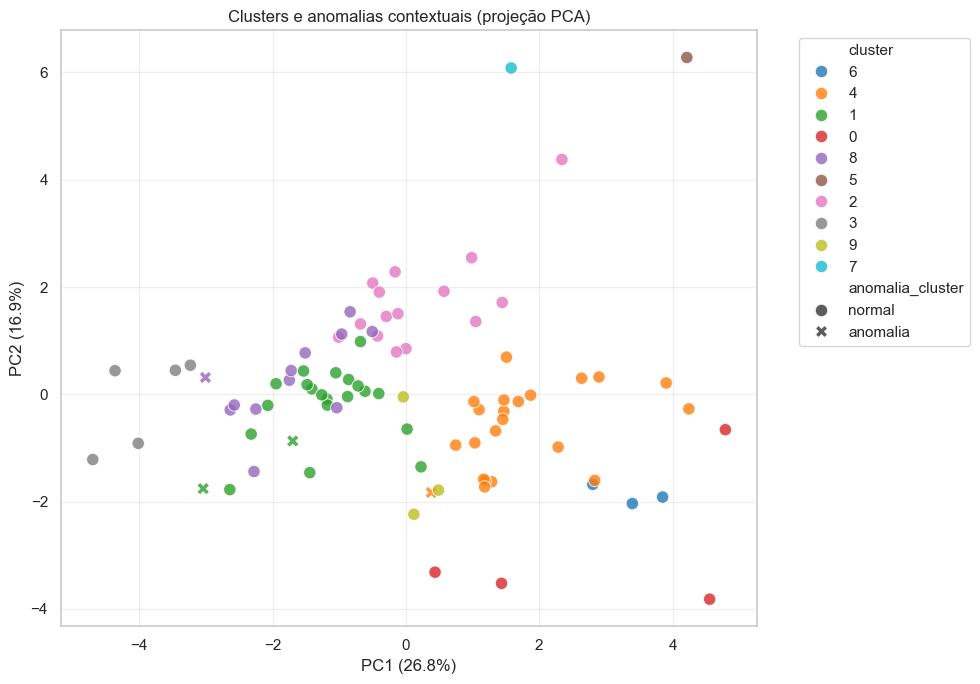

In [8]:
# Comparação Global vs Contextual

print("COMPARAÇÃO: GLOBAL vs CONTEXTUAL")
 
# Usar IsolationForest como base para comparação direta
df_compare = pd.DataFrame(index=X.index)
df_compare["cluster"] = df_anom_clean["cluster"]
df_compare["anomalia_global"] = df_concordancia["anomalia_consenso"]
df_compare["anomalia_cluster"] = df_cluster_results["anomalia_consenso_cluster"]
 
# Crosstab
ct = pd.crosstab(
    df_compare["anomalia_global"], 
    df_compare["anomalia_cluster"],
    margins=True
)
print("\nCrosstab Global vs Contextual (consenso ≥2 métodos):")
display(ct)
 
# Análise de discordâncias
global_sim_cluster_nao = df_compare[
    (df_compare["anomalia_global"] == "anomalia") & 
    (df_compare["anomalia_cluster"] == "normal")
]
global_nao_cluster_sim = df_compare[
    (df_compare["anomalia_global"] == "normal") & 
    (df_compare["anomalia_cluster"] == "anomalia")
]
 
print(f"\nAnómalo global mas normal no cluster: {len(global_sim_cluster_nao)} CPEs")
if len(global_sim_cluster_nao) > 0:
    print("  → Estes CPEs são 'diferentes do global' mas normais dentro do seu grupo")
    display(global_sim_cluster_nao)
 
print(f"\nNormal global mas anómalo no cluster: {len(global_nao_cluster_sim)} CPEs")
if len(global_nao_cluster_sim) > 0:
    print("  → Estes CPEs parecem normais globalmente mas são atípicos no seu grupo")
    display(global_nao_cluster_sim)
 
# Visualização
df_pca_plot = df_pca.copy()
df_pca_plot["cluster"] = df_anom_clean["cluster"]
df_pca_plot["anomalia_global"] = df_concordancia["anomalia_consenso"]
df_pca_plot["anomalia_cluster"] = df_cluster_results["anomalia_consenso_cluster"]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Global
colors_global = ["red" if a == "anomalia" else "blue" for a in df_pca_plot["anomalia_global"]]
axes[0].scatter(df_pca_plot["PC1"], df_pca_plot["PC2"], c=colors_global, alpha=0.7, s=40)
axes[0].set_title(f"Deteção Global (consenso)\n{(df_pca_plot['anomalia_global']=='anomalia').sum()} anomalias")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)
 
# Contextual
colors_cluster = ["red" if a == "anomalia" else "blue" for a in df_pca_plot["anomalia_cluster"]]
axes[1].scatter(df_pca_plot["PC1"], df_pca_plot["PC2"], c=colors_cluster, alpha=0.7, s=40)
axes[1].set_title(f"Deteção Contextual (consenso)\n{(df_pca_plot['anomalia_cluster']=='anomalia').sum()} anomalias")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("Comparação: Deteção Global vs Contextual", fontweight="bold")
plt.tight_layout()
plt.savefig(results_dir / "anomalias_global_vs_cluster.png", dpi=150)
plt.show()
 
# Visualização combinada (cluster + anomalias)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca_plot,
    x="PC1", y="PC2",
    hue="cluster",
    style="anomalia_cluster",
    style_order=["normal", "anomalia"],
    markers={"normal": "o", "anomalia": "X"},
    palette="tab10",
    s=80, alpha=0.8
)
plt.title("Clusters e anomalias contextuais (projeção PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(results_dir / "clusters_anomalias_pca.png", dpi=150, bbox_inches="tight")
plt.show()


FEATURES QUE DISTINGUEM ANOMALIAS

Features com maior diferença entre normais e anómalos:
(effect size = |mean_anom - mean_normal| / std_global)



tendencia_slope         1.705
amplitude_horaria       1.353
iqr                     1.330
std                     1.092
p95                     1.078
mean_dia                1.033
mean                    0.995
hora_pico_utilizacao    0.944
mean_noite              0.944
median                  0.930
dtype: float64

C:\Users\gui30\AppData\Local\Temp\ipykernel_7844\2221931795.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gui30\AppData\Local\Temp\ipykernel_7844\2221931795.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gui30\AppData\Local\Temp\ipykernel_7844\2221931795.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gui30\AppData\Local\Temp\ipykernel_7844\2221931795.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

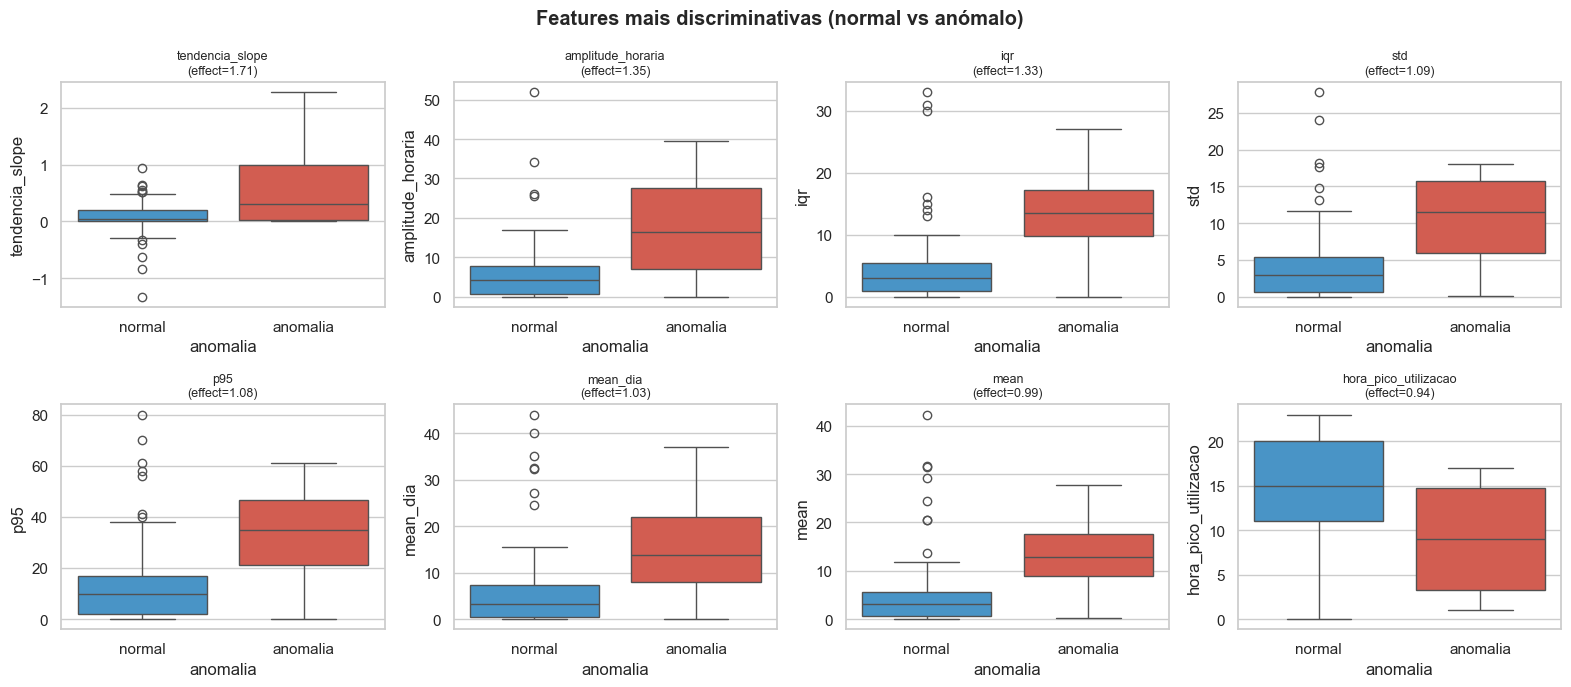

In [9]:
# Análise das features que mais contribuem para anomalias

print("FEATURES QUE DISTINGUEM ANOMALIAS")
 
# Comparar médias de features entre normais e anómalos (contextual)
df_feat_anom = df_anom_clean.copy()
df_feat_anom["anomalia"] = df_cluster_results["anomalia_consenso_cluster"]
 
if (df_feat_anom["anomalia"] == "anomalia").sum() > 0:
    
    feat_cols = [c for c in df_feat_anom.columns if c not in ["cluster", "anomalia"]]
    
    mean_normal = df_feat_anom[df_feat_anom["anomalia"] == "normal"][feat_cols].mean()
    mean_anomalo = df_feat_anom[df_feat_anom["anomalia"] == "anomalia"][feat_cols].mean()
    
    # Diferença normalizada (effect size simplificado)
    std_global = df_feat_anom[feat_cols].std()
    diff_norm = ((mean_anomalo - mean_normal) / std_global).abs().sort_values(ascending=False)
    
    print("\nFeatures com maior diferença entre normais e anómalos:")
    print("(effect size = |mean_anom - mean_normal| / std_global)\n")
    display(diff_norm.head(10).round(3))
    
    # Gráfico
    top_features = diff_norm.head(8).index.tolist()
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    
    for i, feat in enumerate(top_features):
        if i < len(axes):
            sns.boxplot(
                data=df_feat_anom, x="anomalia", y=feat, 
                ax=axes[i], palette={"normal": "#3498DB", "anomalia": "#E74C3C"}
            )
            axes[i].set_title(f"{feat}\n(effect={diff_norm[feat]:.2f})", fontsize=9)
    
    for j in range(len(top_features), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Features mais discriminativas (normal vs anómalo)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(results_dir / "features_discriminativas.png", dpi=150)
    plt.show()
 
else:
    print("Nenhuma anomalia detetada por consenso contextual.")

In [10]:
# Análise de sensibilidade ao contamination

print("SENSIBILIDADE AO CONTAMINATION")
 
contam_range = [0.02, 0.05, 0.08, 0.10, 0.15]
sensibilidade = []
 
for contam in contam_range:
    iso_s = IsolationForest(contamination=contam, random_state=42)
    labels_s = iso_s.fit_predict(X_scaled)
    n_anom = (labels_s == -1).sum()
    
    sensibilidade.append({
        "contamination": contam,
        "n_anomalias": n_anom,
        "pct_anomalias": n_anom / len(labels_s) * 100,
        "cpes_anomalos": set(X.index[labels_s == -1].tolist())
    })
 
df_sens = pd.DataFrame(sensibilidade)[["contamination", "n_anomalias", "pct_anomalias"]]
display(df_sens)
 
# Estabilidade: quais CPEs são consistentemente anómalos?
todos_anom_sets = [s["cpes_anomalos"] for s in sensibilidade]
sempre_anomalo = set.intersection(*todos_anom_sets) if todos_anom_sets else set()
 
print(f"\nCPEs anómalos em TODOS os níveis de contamination testados:")
if sempre_anomalo:
    for cpe in sempre_anomalo:
        print(f"  {cpe}")
else:
    print("  Nenhum (os resultados variam com o contamination)")
 
# Frequência com que cada CPE é classificado como anómalo
freq_anomalo = {}
for s in sensibilidade:
    for cpe in s["cpes_anomalos"]:
        freq_anomalo[cpe] = freq_anomalo.get(cpe, 0) + 1
 
if freq_anomalo:
    df_freq = (
        pd.Series(freq_anomalo, name="n_vezes_anomalo")
        .sort_values(ascending=False)
        .to_frame()
    )
    df_freq["pct_configs"] = df_freq["n_vezes_anomalo"] / len(contam_range) * 100
    print(f"\nFrequência de classificação como anómalo (IsolationForest global):")
    display(df_freq)


SENSIBILIDADE AO CONTAMINATION


,contamination,n_anomalias,pct_anomalias
0,0.02,2,2.272727
1,0.05,5,5.681818
2,0.08,7,7.954545
3,0.10,9,10.227273
4,0.15,14,15.909091



CPEs anómalos em TODOS os níveis de contamination testados:
  PT0002000068859325FL
  PT0002000100113293JT

Frequência de classificação como anómalo (IsolationForest global):


,n_vezes_anomalo,pct_configs
PT0002000068859325FL,5,100.0
PT0002000100113293JT,5,100.0
PT0002000068856781NM,4,80.0
PT0002000068859597LS,4,80.0
PT0002000081997398TD,4,80.0
PT0002000068859393XH,3,60.0
PT0002000068859382XF,3,60.0
PT0002000065256275YB,2,40.0
PT0002000112989585PH,2,40.0
PT0002000071896778MT,1,20.0


In [11]:
# Exportação de resultados

# Resultados contextuais (principal)
export_cluster = df_cluster_results[
    ["cluster"] + label_cols + ["n_metodos_anomalo_cluster", "anomalia_consenso_cluster"]
].copy()
export_cluster.to_csv(results_dir / "anomalias_por_cluster.csv")
print("\nAnomalias por cluster guardadas:", results_dir / "anomalias_por_cluster.csv")
 
# Resultados globais
export_global = df_concordancia.copy()
export_global.to_csv(results_dir / "anomalias_globais.csv")
print("Anomalias globais guardadas:", results_dir / "anomalias_globais.csv")
 
# Resumo combinado
export_compare = df_compare.copy()
export_compare.to_csv(results_dir / "anomalias_comparacao.csv")
print("Comparação global vs cluster guardada:", results_dir / "anomalias_comparacao.csv")


Anomalias por cluster guardadas: ..\results\anomalias_por_cluster.csv
Anomalias globais guardadas: ..\results\anomalias_globais.csv
Comparação global vs cluster guardada: ..\results\anomalias_comparacao.csv


# Conclusões

A deteção de anomalias ao nível das features agregadas foi realizada com múltiplos métodos (IsolationForest, LOF, EllipticEnvelope) em duas abordagens: global e contextual (por cluster).

Principais conclusões:
- O uso de consenso (≥2 métodos) reduz falsos positivos
- A abordagem contextual é mais precisa que a global
- A análise de sensibilidade ao contamination mostra a robustez dos resultados
- As features mais discriminativas podem guiar a interpretação das anomalias

Próximo passo: deteção de anomalias diretamente nas séries temporais